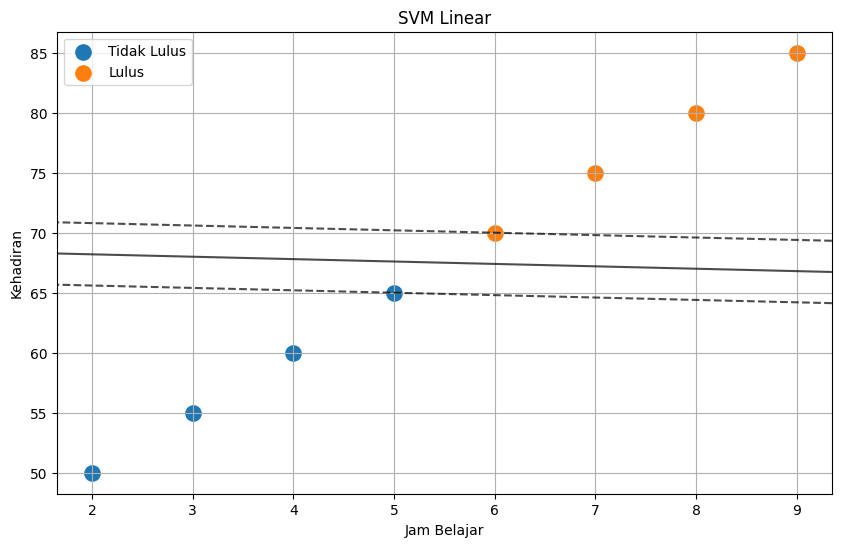

In [1]:
# ==========================================================
# SVM LINEAR
# Kasus: Prediksi Kelulusan Mahasiswa
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# ==========================================================
# DATASET
# ==========================================================

X = np.array([
    [2,50],
    [3,55],
    [4,60],
    [5,65],
    [6,70],
    [7,75],
    [8,80],
    [9,85]
])

y = np.array([0,0,0,0,1,1,1,1])

# ==========================================================
# MODEL SVM LINEAR
# ==========================================================

model = SVC(
    kernel='linear',
    C=1
)

model.fit(X, y)

# ==========================================================
# VISUALISASI
# ==========================================================

plt.figure(figsize=(10,6))

# Scatter plot
plt.scatter(
    X[y==0][:,0],
    X[y==0][:,1],
    s=120,
    label='Tidak Lulus'
)

plt.scatter(
    X[y==1][:,0],
    X[y==1][:,1],
    s=120,
    label='Lulus'
)

# ==========================================================
# HYPERPLANE
# ==========================================================

ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

# Garis hyperplane
ax.contour(
    XX,
    YY,
    Z,
    colors='black',
    levels=[-1,0,1],
    alpha=0.7,
    linestyles=['--','-','--']
)

# ==========================================================
# LABEL
# ==========================================================

plt.xlabel("Jam Belajar")
plt.ylabel("Kehadiran")
plt.title("SVM Linear")

plt.legend()

plt.grid(True)

plt.show()

=== HASIL PREDIKSI DATA UJI ===
Data 1 -> Jam Belajar=4.5, Kehadiran=62.0 => Prediksi=0
Data 2 -> Jam Belajar=5.5, Kehadiran=68.0 => Prediksi=1
Data 3 -> Jam Belajar=6.5, Kehadiran=72.0 => Prediksi=1
Data 4 -> Jam Belajar=7.5, Kehadiran=78.0 => Prediksi=1


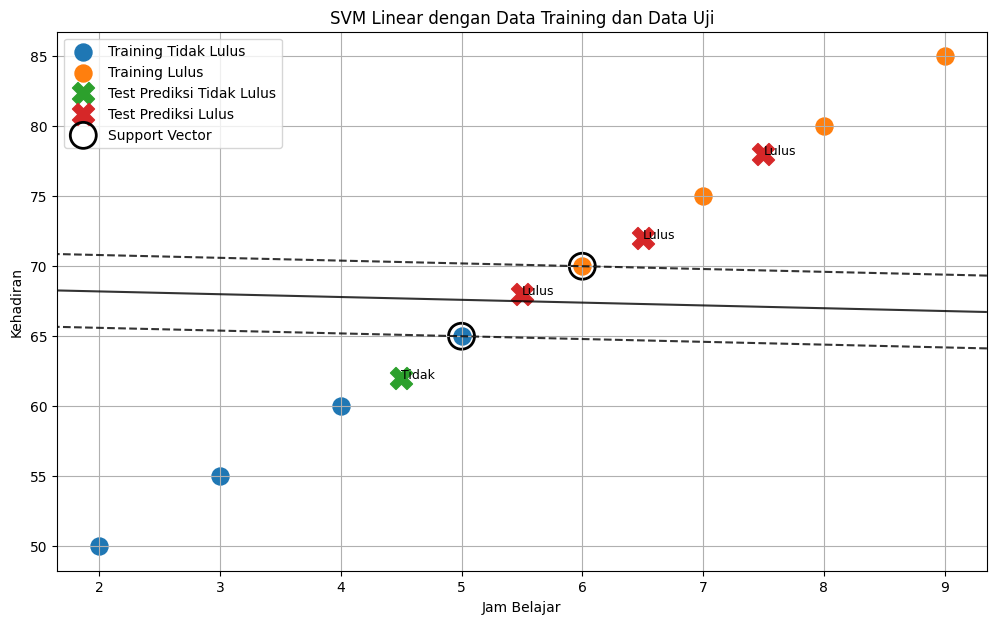

In [2]:
# ==========================================================
# SVM LINEAR
# DENGAN DATA TRAINING DAN DATA UJI
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# ==========================================================
# DATA TRAINING
# ==========================================================

X_train = np.array([
    [2,50],
    [3,55],
    [4,60],
    [5,65],
    [6,70],
    [7,75],
    [8,80],
    [9,85]
])

y_train = np.array([0,0,0,0,1,1,1,1])

# ==========================================================
# DATA UJI
# ==========================================================

X_test = np.array([
    [4.5,62],
    [5.5,68],
    [6.5,72],
    [7.5,78]
])

# ==========================================================
# MODEL SVM LINEAR
# ==========================================================

model = SVC(
    kernel='linear',
    C=1
)

model.fit(X_train, y_train)

# ==========================================================
# PREDIKSI DATA UJI
# ==========================================================

y_pred = model.predict(X_test)

print("=== HASIL PREDIKSI DATA UJI ===")

for i in range(len(X_test)):
    print(
        f"Data {i+1} -> "
        f"Jam Belajar={X_test[i][0]}, "
        f"Kehadiran={X_test[i][1]} "
        f"=> Prediksi={y_pred[i]}"
    )

# ==========================================================
# VISUALISASI
# ==========================================================

plt.figure(figsize=(12,7))

# ==========================================================
# DATA TRAINING
# ==========================================================

plt.scatter(
    X_train[y_train==0][:,0],
    X_train[y_train==0][:,1],
    s=150,
    label='Training Tidak Lulus'
)

plt.scatter(
    X_train[y_train==1][:,0],
    X_train[y_train==1][:,1],
    s=150,
    label='Training Lulus'
)

# ==========================================================
# DATA UJI
# ==========================================================

plt.scatter(
    X_test[y_pred==0][:,0],
    X_test[y_pred==0][:,1],
    s=250,
    marker='X',
    label='Test Prediksi Tidak Lulus'
)

plt.scatter(
    X_test[y_pred==1][:,0],
    X_test[y_pred==1][:,1],
    s=250,
    marker='X',
    label='Test Prediksi Lulus'
)

# ==========================================================
# ANOTASI DATA UJI
# ==========================================================

for i in range(len(X_test)):

    label = "Lulus" if y_pred[i] == 1 else "Tidak"

    plt.text(
        X_test[i][0],
        X_test[i][1],
        label,
        fontsize=9
    )

# ==========================================================
# HYPERPLANE
# ==========================================================

ax = plt.gca()

xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)

YY, XX = np.meshgrid(yy, xx)

xy = np.vstack([XX.ravel(), YY.ravel()]).T

Z = model.decision_function(xy).reshape(XX.shape)

# Hyperplane dan margin
ax.contour(
    XX,
    YY,
    Z,
    colors='black',
    levels=[-1,0,1],
    alpha=0.8,
    linestyles=['--','-','--']
)

# ==========================================================
# SUPPORT VECTOR
# ==========================================================

plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=350,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vector'
)

# ==========================================================
# LABEL
# ==========================================================

plt.xlabel("Jam Belajar")
plt.ylabel("Kehadiran")

plt.title("SVM Linear dengan Data Training dan Data Uji")

plt.legend()

plt.grid(True)

plt.show()